In [18]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, average_precision_score, confusion_matrix, classification_report

In [19]:
df_model = pd.read_csv("data/processed/accepted_model_base.csv")
print(df_model.shape)
df_model.head()

(1371166, 24)


,loan_amnt,term,installment,emp_length,home_ownership,annual_inc,verification_status,issue_d,purpose,addr_state,...,pub_rec,revol_bal,revol_util,total_acc,mort_acc,pub_rec_bankruptcies,fico_avg,credit_history_years,loan_status,target_bad
0,3600.0,36.0,123.03,10+ years,MORTGAGE,55000.0,Not Verified,2015-12-01,debt_consolidation,PA,...,0.0,2765.0,29.7,13.0,1.0,0.0,677.0,12.334018,Fully Paid,0
1,24700.0,36.0,820.28,10+ years,MORTGAGE,65000.0,Not Verified,2015-12-01,small_business,SD,...,0.0,21470.0,19.2,38.0,4.0,0.0,717.0,16.000000,Fully Paid,0
2,20000.0,60.0,432.66,10+ years,MORTGAGE,63000.0,Not Verified,2015-12-01,home_improvement,IL,...,0.0,7869.0,56.2,18.0,5.0,0.0,697.0,15.331964,Fully Paid,0
3,10400.0,60.0,289.91,3 years,MORTGAGE,104433.0,Source Verified,2015-12-01,major_purchase,PA,...,0.0,21929.0,64.5,35.0,6.0,0.0,697.0,17.500342,Fully Paid,0
4,11950.0,36.0,405.18,4 years,RENT,34000.0,Source Verified,2015-12-01,debt_consolidation,GA,...,0.0,8822.0,68.4,6.0,0.0,0.0,692.0,28.167009,Fully Paid,0


In [20]:
df_model["issue_d"] = pd.to_datetime(df_model["issue_d"], errors="coerce")

In [21]:
train_df = df_model[df_model["issue_d"] < "2016-01-01"].copy()
valid_df = df_model[(df_model["issue_d"] >= "2016-01-01") & (df_model["issue_d"] < "2017-01-01")].copy()
test_df = df_model[df_model["issue_d"] >= "2017-01-01"].copy()

print(train_df.shape, valid_df.shape, test_df.shape)

(828654, 24) (298553, 24) (243959, 24)


In [22]:
print(train_df["issue_d"].min(), train_df["issue_d"].max())
print(valid_df["issue_d"].min(), valid_df["issue_d"].max())
print(test_df["issue_d"].min(), test_df["issue_d"].max())

2007-06-01 00:00:00 2015-12-01 00:00:00
2016-01-01 00:00:00 2016-12-01 00:00:00
2017-01-01 00:00:00 2018-12-01 00:00:00


In [23]:
print(df_model["issue_d"].min())
print(df_model["issue_d"].max())
print(df_model["issue_d"].dt.year.value_counts().sort_index())

2007-06-01 00:00:00
2018-12-01 00:00:00
issue_d
2007       251
2008      1562
2009      4716
2010     11536
2011     21721
2012     53367
2013    134807
2014    223510
2015    377184
2016    298553
2017    178817
2018     65142
Name: count, dtype: int64


In [24]:
drop_cols = ["loan_status", "target_bad", "issue_d"]

X_train = train_df.drop(columns=drop_cols)
y_train = train_df["target_bad"]

X_valid = valid_df.drop(columns=drop_cols)
y_valid = valid_df["target_bad"]

X_test = test_df.drop(columns=drop_cols)
y_test = test_df["target_bad"]

In [25]:
numeric_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = X_train.select_dtypes(exclude=[np.number]).columns.tolist()

print("Numeric:", numeric_cols)
print("Categorical:", categorical_cols)

Numeric: ['loan_amnt', 'term', 'installment', 'annual_inc', 'dti', 'delinq_2yrs', 'inq_last_6mths', 'open_acc', 'pub_rec', 'revol_bal', 'revol_util', 'total_acc', 'mort_acc', 'pub_rec_bankruptcies', 'fico_avg', 'credit_history_years']
Categorical: ['emp_length', 'home_ownership', 'verification_status', 'purpose', 'addr_state']


In [26]:
numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numeric_cols),
    ("cat", categorical_transformer, categorical_cols),
])

In [27]:
logit_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=2000))
])

logit_model.fit(X_train, y_train)

valid_pred_logit = logit_model.predict_proba(X_valid)[:, 1]
test_pred_logit = logit_model.predict_proba(X_test)[:, 1]

print("Validation ROC AUC:", roc_auc_score(y_valid, valid_pred_logit))
print("Validation PR AUC:", average_precision_score(y_valid, valid_pred_logit))
print("Test ROC AUC:", roc_auc_score(y_test, test_pred_logit))
print("Test PR AUC:", average_precision_score(y_test, test_pred_logit))

Validation ROC AUC: 0.6978850389702217
Validation PR AUC: 0.4258119386027211
Test ROC AUC: 0.6869798626305741
Test PR AUC: 0.4295739778977719


In [28]:
test_label_logit = (test_pred_logit >= 0.5).astype(int)

print(confusion_matrix(y_test, test_label_logit))
print(classification_report(y_test, test_label_logit))

[[174097   3499]
 [ 61653   4710]]
              precision    recall  f1-score   support

           0       0.74      0.98      0.84    177596
           1       0.57      0.07      0.13     66363

    accuracy                           0.73    243959
   macro avg       0.66      0.53      0.48    243959
weighted avg       0.69      0.73      0.65    243959



In [29]:
from sklearn.metrics import confusion_matrix, classification_report

for thresh in [0.15, 0.20, 0.25, 0.30, 0.35]:
    preds = (test_pred_logit >= thresh).astype(int)
    cm = confusion_matrix(y_test, preds)
    print(f"\nThreshold = {thresh}")
    print(cm)
    print(classification_report(y_test, preds, digits=3))


Threshold = 0.15
[[98526 79070]
 [18899 47464]]
              precision    recall  f1-score   support

           0      0.839     0.555     0.668    177596
           1      0.375     0.715     0.492     66363

    accuracy                          0.598    243959
   macro avg      0.607     0.635     0.580    243959
weighted avg      0.713     0.598     0.620    243959


Threshold = 0.2
[[129344  48252]
 [ 31591  34772]]
              precision    recall  f1-score   support

           0      0.804     0.728     0.764    177596
           1      0.419     0.524     0.466     66363

    accuracy                          0.673    243959
   macro avg      0.611     0.626     0.615    243959
weighted avg      0.699     0.673     0.683    243959


Threshold = 0.25
[[146546  31050]
 [ 40993  25370]]
              precision    recall  f1-score   support

           0      0.781     0.825     0.803    177596
           1      0.450     0.382     0.413     66363

    accuracy                

In [30]:
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score

rows = []
for thresh in [0.10, 0.15, 0.20, 0.25, 0.30, 0.35]:
    preds = (test_pred_logit >= thresh).astype(int)
    rows.append({
        "threshold": thresh,
        "accuracy": accuracy_score(y_test, preds),
        "precision_bad": precision_score(y_test, preds, zero_division=0),
        "recall_bad": recall_score(y_test, preds, zero_division=0),
        "f1_bad": f1_score(y_test, preds, zero_division=0),
        "flag_rate": preds.mean()
    })

threshold_results = pd.DataFrame(rows)
threshold_results

,threshold,accuracy,precision_bad,recall_bad,f1_bad,flag_rate
0,0.10,0.465722,0.325262,0.897277,0.477449,0.750417
1,0.15,0.598420,0.375109,0.715218,0.492118,0.518669
2,0.20,0.672720,0.418819,0.523967,0.465529,0.340319
3,0.25,0.704692,0.449663,0.382291,0.413249,0.231268
4,0.30,0.720351,0.476626,0.285762,0.357302,0.163093
5,0.35,0.728536,0.502417,0.214532,0.300676,0.116155


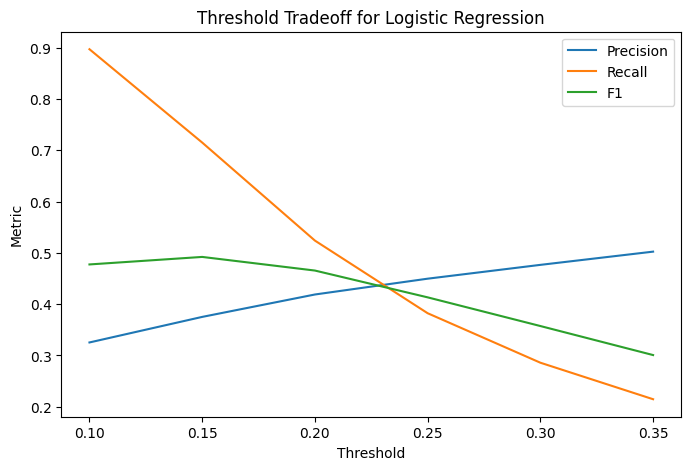

In [31]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(threshold_results["threshold"], threshold_results["precision_bad"], label="Precision")
plt.plot(threshold_results["threshold"], threshold_results["recall_bad"], label="Recall")
plt.plot(threshold_results["threshold"], threshold_results["f1_bad"], label="F1")
plt.xlabel("Threshold")
plt.ylabel("Metric")
plt.title("Threshold Tradeoff for Logistic Regression")
plt.legend()
plt.show()

In [32]:
test_results = test_df.copy()
test_results["pred_logit"] = test_pred_logit
test_results["decile"] = pd.qcut(test_results["pred_logit"], 10, labels=False, duplicates="drop")

decile_summary = test_results.groupby("decile").agg(
    n=("target_bad", "size"),
    avg_pred=("pred_logit", "mean"),
    actual_bad_rate=("target_bad", "mean")
).reset_index()

decile_summary

,decile,n,avg_pred,actual_bad_rate
0,0,24396,0.045144,0.073701
1,1,24396,0.076826,0.126578
2,2,24396,0.100026,0.169782
3,3,24396,0.121288,0.208026
4,4,24396,0.143036,0.244138
5,5,24395,0.167093,0.282640
6,6,24396,0.197048,0.326652
7,7,24396,0.240410,0.367724
8,8,24396,0.315276,0.409083
9,9,24396,0.483642,0.511928


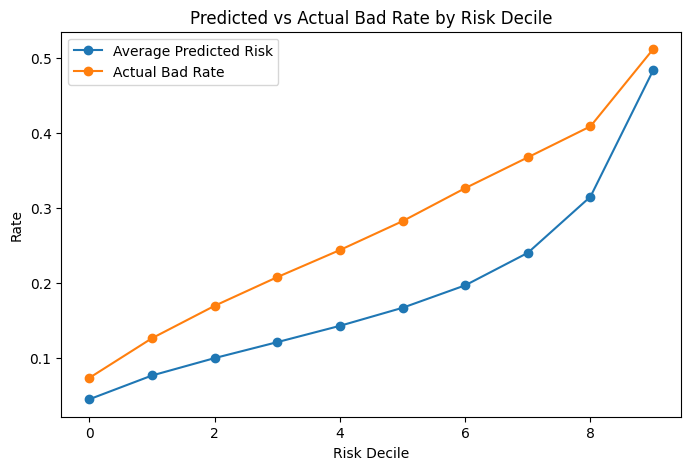

In [33]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(decile_summary["decile"], decile_summary["avg_pred"], marker="o", label="Average Predicted Risk")
plt.plot(decile_summary["decile"], decile_summary["actual_bad_rate"], marker="o", label="Actual Bad Rate")
plt.xlabel("Risk Decile")
plt.ylabel("Rate")
plt.title("Predicted vs Actual Bad Rate by Risk Decile")
plt.legend()
plt.show()

In [34]:
import pandas as pd
from pathlib import Path

out_dir = Path("data/processed")
out_dir.mkdir(parents=True, exist_ok=True)

pd.DataFrame({
    "y_valid": y_valid.reset_index(drop=True),
    "pred_logit": pd.Series(valid_pred_logit).reset_index(drop=True),
}).to_csv(out_dir / "logit_valid_predictions.csv", index=False)

pd.DataFrame({
    "y_test": y_test.reset_index(drop=True),
    "pred_logit": pd.Series(test_pred_logit).reset_index(drop=True),
}).to_csv(out_dir / "logit_test_predictions.csv", index=False)